# Network Intrusion Detection with Machine Learning & SHAP Explainability
**Dataset:** NSL-KDD | **Model:** Logistic Regression | **Tools:** Python, Scikit-learn, SHAP

## Project Overview
This project applies machine learning to the NSL-KDD network intrusion dataset to classify 
network connections as normal or malicious. Beyond prediction accuracy, this analysis uses 
SHAP (SHapley Additive exPlanations) to explain *why* the model flags specific connections 
as attacks — translating model outputs into actionable security insights.

**Business Question:** Can we accurately detect malicious network connections, and can we 
explain the detection in terms a security analyst can act on?

## 1. Data Loading & Understanding
The NSL-KDD dataset contains 125,973 network connection records with 41 features 
capturing traffic behavior — protocol type, connection duration, error rates, and more.
Each row represents one network connection labeled as either normal or a specific attack type.

**Attack categories present in this dataset:**
- **DoS (Denial of Service):** neptune, smurf, pod, teardrop, back — overwhelm a system to deny access
- **Probe:** portsweep, ipsweep, satan, nmap — scan and map network vulnerabilities
- **R2L (Remote to Local):** warezclient, warezmaster, guess_passwd, ftp_write — unauthorized remote access
- **U2R (User to Root):** buffer_overflow, rootkit, loadmodule, perl — privilege escalation attacks

For this model we simplify to binary classification: **normal vs. attack.**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
# Load NSL-KDD training data and assign column names
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

df = pd.read_csv(r"C:\Users\DELL 5300\Downloads\archive (5)\nsl-kdd\KDDTrain+.txt", names=columns)

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
df.shape

(125973, 43)

In [4]:
print(df.dtypes)

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [5]:
print(df['label'].value_counts())

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


## 2. Data Preparation
Before training, three things need to happen:

1. **Drop irrelevant columns** — `difficulty` is metadata about the dataset itself, not a network feature
2. **Encode categorical columns** — `protocol_type`, `service`, and `flag` are text values. 
Logistic Regression requires numbers, so we convert them using Label Encoding
3. **Create binary target** — instead of 23 attack categories, we reduce to: 0 = normal, 1 = attack

This binary framing mirrors real SOC alerting logic — detect first, classify the attack type second.

In [6]:
# Drop difficulty - not a feature
df.drop(columns=['difficulty'], inplace=True)

In [7]:
# Encode categorical features and create binary target label
# Binary label: normal = 0, attack = 1
df['label_binary'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Encode categorical columns
for col in ['protocol_type', 'service', 'flag']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [8]:
df.drop(columns=['label'], inplace=True)
print(df.columns.tolist())

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label_binary']


In [9]:
# Confirm
print(df['label_binary'].value_counts())
print(df.dtypes.unique())

label_binary
0    67343
1    58630
Name: count, dtype: int64
[dtype('int64') dtype('int32') dtype('float64')]


In [10]:
print(df.shape)

(125973, 42)


## 3. Model Training
We use **Logistic Regression** as our first model deliberately — not because it's the most 
powerful, but because:

1. **Interpretability** — coefficients show which features drive predictions globally
2. **Baseline** — establishes a performance benchmark before trying complex models
3. **Speed** — trains quickly on large datasets

**Key decisions:**
- 80/20 train/test split with stratification to preserve class balance
- StandardScaler applied before training — Logistic Regression is sensitive to feature scale
- `max_iter=1000` to ensure the model fully converges

In security analytics, an explainable model that performs well is more valuable than a 
black-box model that performs slightly better but can't justify its decisions.

In [11]:
# Split data, scale features, and train Logistic Regression classifier
# Split features and target
X = df.drop(columns=['label_binary'])
y = df['label_binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features - Logistic Regression needs this
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Training complete")

Training complete


## 4. Model Evaluation
We evaluate using three metrics — each answers a different question:

- **Precision** — of all connections flagged as attacks, how many were actually attacks? 
  Low precision = too many false alarms, wasting analyst time
- **Recall** — of all actual attacks, how many did the model catch? 
  Low recall = attacks slipping through undetected — the more dangerous failure in security
- **F1-Score** — single number balancing both precision and recall

**In security, recall is prioritized over precision.**
A missed attack is always more costly than a false alarm.

The confusion matrix breaks this down visually showing exactly where the model 
is getting it right and where it is getting confused.

              precision    recall  f1-score   support

      normal       0.95      0.96      0.96     13469
      attack       0.96      0.94      0.95     11726

    accuracy                           0.95     25195
   macro avg       0.95      0.95      0.95     25195
weighted avg       0.95      0.95      0.95     25195



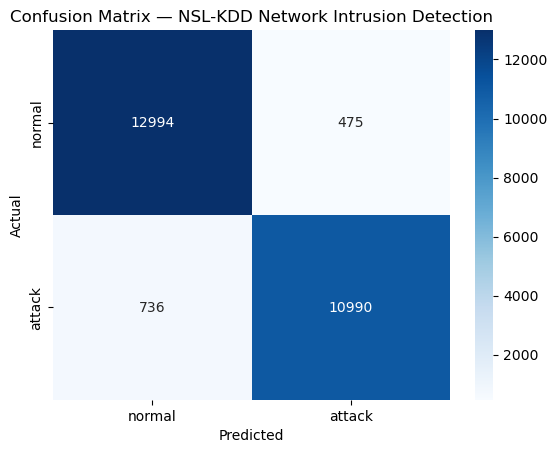

In [12]:
# Evaluate model performance using classification report and confusion matrix
# Predictions
y_pred = model.predict(X_test_scaled)

# Classification report
print(classification_report(y_test, y_pred, target_names=['normal', 'attack']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'attack'],
            yticklabels=['normal', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — NSL-KDD Network Intrusion Detection')
plt.show()

## 4b. Feature Importance (Model Coefficients)
Before SHAP, we extract global feature importance directly from the Logistic Regression 
coefficients. Each coefficient tells us:

- **High positive coefficient** — feature strongly pushes prediction toward attack
- **High negative coefficient** — feature strongly pushes prediction toward normal
- **Magnitude (absolute value)** — how influential the feature is overall

**Limitation of coefficients:**
Coefficients give one value per feature across the entire dataset they cannot explain 
why a *specific* connection was flagged. That is what SHAP solves.

This is why we use both coefficients for quick global understanding, 
SHAP for deep individual explanation.

In [13]:
# Extract and rank feature coefficients to identify top attack indicators
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
})

feature_importance['abs_coef'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

print(feature_importance.head(10))

               feature  coefficient  abs_coef
15            num_root    -5.850727  5.850727
12     num_compromised     5.693017  5.693017
25     srv_serror_rate     2.593474  2.593474
21      is_guest_login    -2.052252  2.052252
7       wrong_fragment     2.038539  2.038539
9                  hot     1.880115  1.880115
22               count     1.853475  1.853475
27     srv_rerror_rate     1.646527  1.646527
32  dst_host_srv_count    -1.474180  1.474180
3                 flag     1.221645  1.221645


## 5. SHAP Explainability
Accuracy metrics tell you *how well* the model performs. SHAP tells you *why* it makes 
each decision.

SHAP (SHapley Additive exPlanations) assigns each feature a value for every prediction:
- **Positive SHAP value** — feature pushed the prediction toward attack
- **Negative SHAP value** — feature pushed the prediction toward normal
- **Value close to zero** — feature had little influence on this prediction

**Two levels of explanation:**
- **Summary Plot (Global)** — which features matter most across all connections
- **Waterfall Plot (Local)** — why one specific connection was flagged as an attack

This dual explanation is what separates security data analysis from generic ML 
you can hand a SOC analyst a flagged connection and tell them exactly what triggered it.

In [14]:
import shap
print(shap.__version__)

0.51.0


In [15]:
# Use a sample of 500 rows - SHAP on full dataset is slow
sample = X_test_scaled[:500]

# Create explainer
explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer(sample)

print("SHAP values computed")
print(shap_values.shape)

SHAP values computed
(500, 41)


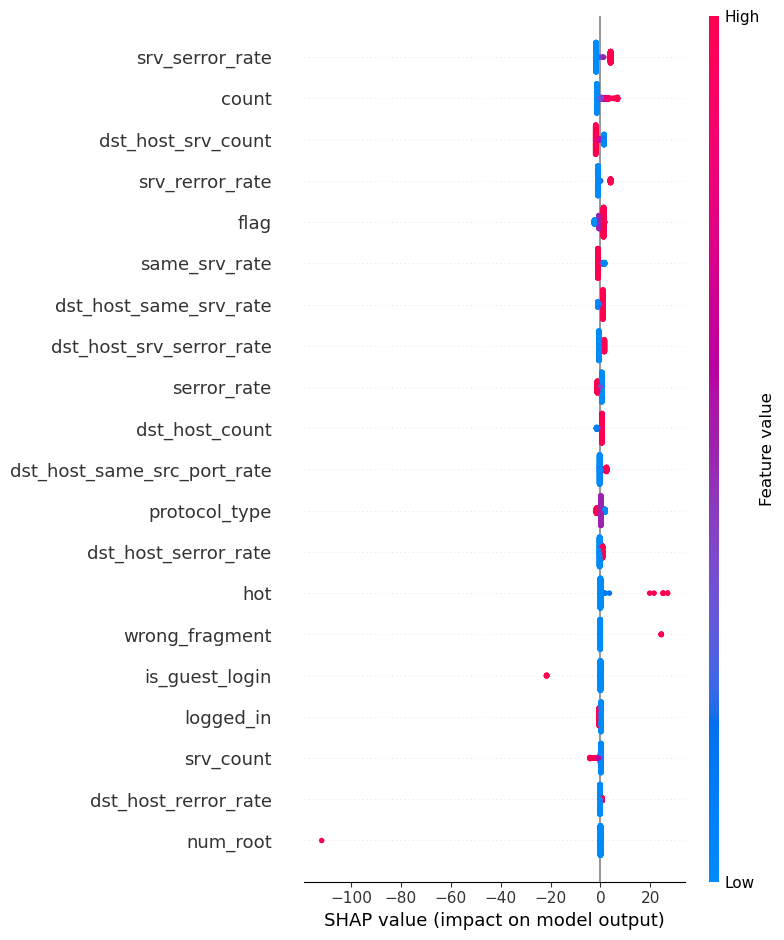

In [16]:
# Summary plot - shows which features matter most across all 500 connections
shap.summary_plot(shap_values, features=sample, feature_names=X.columns.tolist())

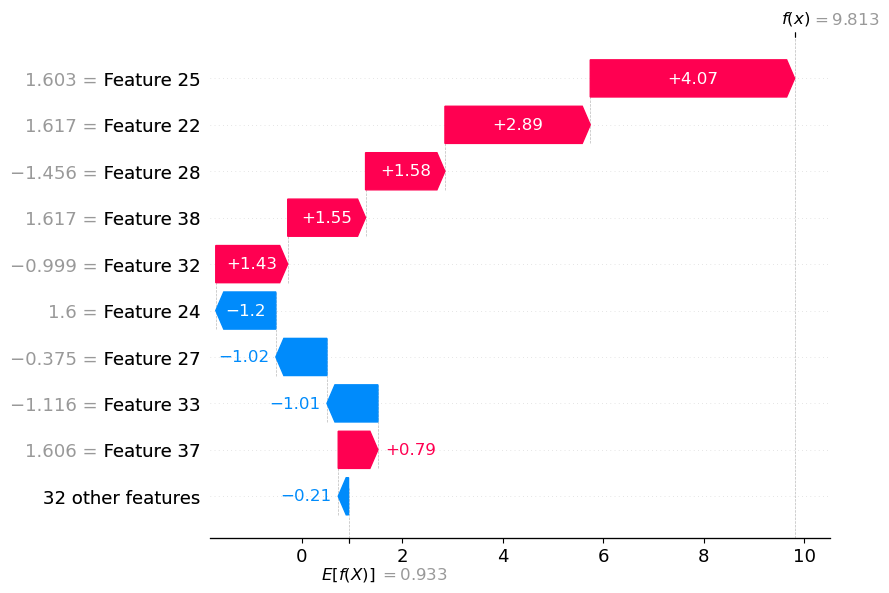

In [17]:
# Explain the first connection in the sample
shap.plots.waterfall(shap_values[0])

In [18]:
print(X.columns[25])

srv_serror_rate


In [19]:
print(model)
print(shap_values.shape)

LogisticRegression(max_iter=1000, random_state=42)
(500, 41)


## 6. ROC Curve Analysis
The ROC curve plots the tradeoff between:
- **True Positive Rate (Recall)** — attacks correctly caught
- **False Positive Rate** — normal traffic wrongly flagged as attacks

At every possible decision threshold, the curve shows how the model balances 
catching attacks against generating false alarms.

**AUC Score: 0.992**
A score of 1.0 is perfect. At 0.992, the model near-perfectly separates attack 
from normal traffic across all thresholds  meaning a SOC team can tune the 
detection threshold to their environment without significantly sacrificing either 
catch rate or false alarm rate.

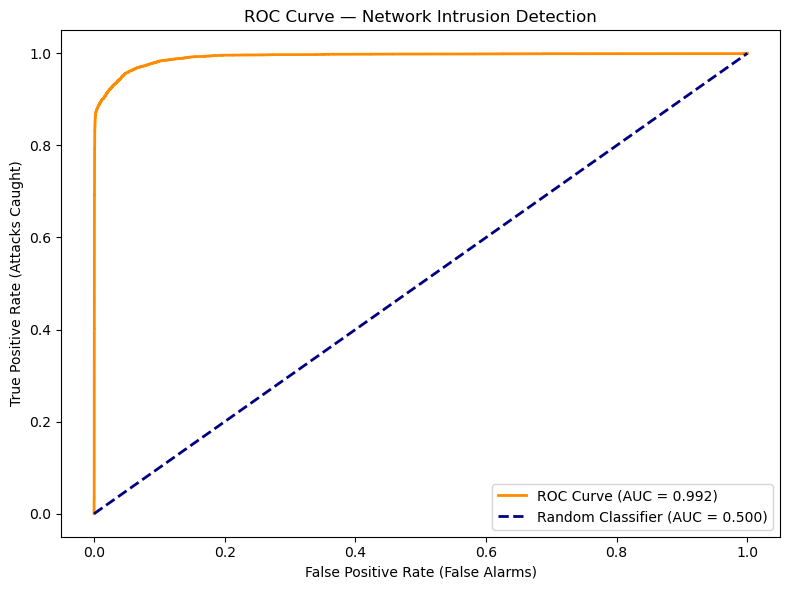

AUC Score: 0.992


In [20]:
# Get probability scores instead of binary predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Attacks Caught)')
plt.title('ROC Curve — Network Intrusion Detection')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.3f}")

## 7. False Negative Analysis — Why Did the Model Miss This Attack?
A false negative is an actual attack the model classified as normal. 
These are the most dangerous model failures in security.

**This connection had:**
- `hot` pushing strongly toward attack (+1.78) — sensitive file access detected
- 6 other features pushing toward normal — connection behavior looked legitimate

**Result:** The model scored this connection at -1.546 — leaning normal — and missed the attack.

**Security implication:** This pattern is consistent with a low-and-slow attack — 
an adversary accessing sensitive resources while keeping all other connection 
behavior within normal ranges to avoid detection. These attacks evade signature-based 
detection and require behavioral analytics over time to catch reliably.

**This is a known limitation of single-connection classification.** 
A more robust system would analyze sequences of connections per host over time, 
not individual connections in isolation.

In [21]:
# Get predictions and probabilities
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Find false negatives — actual attacks the model called normal
false_negatives = np.where((y_test.values == 1) & (y_pred == 0))[0]

print(f"Total false negatives: {len(false_negatives)}")
print(f"First false negative index: {false_negatives[0]}")

Total false negatives: 736
First false negative index: 84


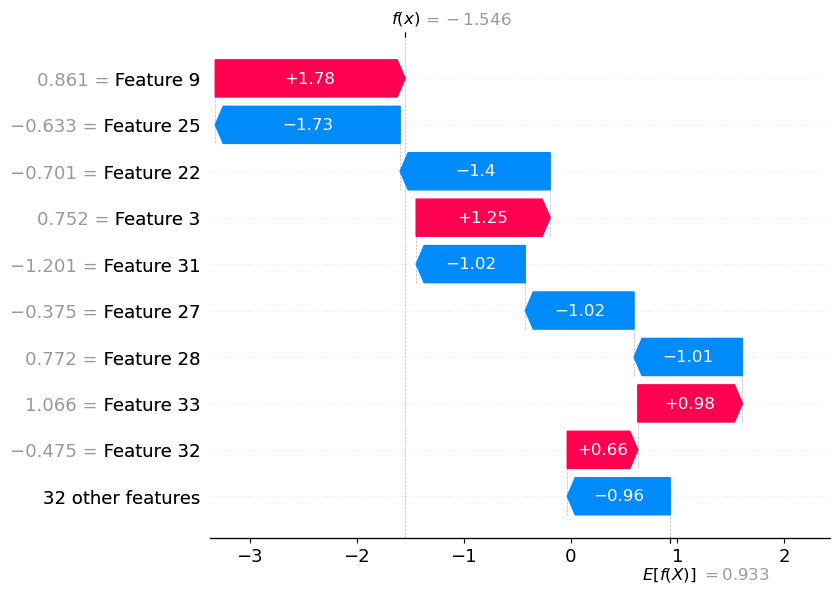

In [22]:
# Get SHAP values for the false negative connection
fn_index = false_negatives[0]
fn_sample = X_test_scaled[fn_index].reshape(1, -1)

# Compute SHAP values for this specific connection
fn_explainer = shap.LinearExplainer(model, X_train_scaled)
fn_shap_values = fn_explainer(fn_sample)

# Plot
shap.plots.waterfall(fn_shap_values[0])

In [23]:
print(X.columns[9])

hot


## 8. Security Insights Summary

### Model Performance
- **Overall Accuracy:** 95% — the model correctly classifies 95 out of 100 connections
- **Attack Recall:** 94% — catches 94% of real attacks, missing only 6%
- **Attack Precision:** 96% — when it raises an alarm, it is right 96% of the time
- **False Negatives:** 736 connections — attacks that slipped through as normal
- **False Positives:** 475 connections — normal traffic incorrectly flagged as attacks

### Key Features Driving Attack Detection
| Feature | Direction | Security Meaning |
|---------|-----------|-----------------|
| `srv_serror_rate` | → Attack | High SYN error rate — consistent with SYN flood or port scan |
| `num_compromised` | → Attack | Compromised conditions detected in the connection |
| `wrong_fragment` | → Attack | Malformed packets — common in evasion and DoS attacks |
| `hot` | → Attack | Sensitive file or directory access attempts |
| `count` | → Attack | High volume of connections to same host — scanning behavior |

### SHAP Finding
Individual connection analysis confirms `srv_serror_rate` as the dominant attack signal — 
connections with high SYN error rates to the same service receive SHAP values exceeding 
+4.0, strongly pushing predictions toward attack classification.

### Limitations & Next Steps
- Binary classification catches attacks but does not identify attack type
- **False negative rate of 6% (736 connections)** — some attacks evade detection
- False negative analysis reveals a low-and-slow attack pattern — sensitive file 
  access (`hot`) present but all other connection behavior within normal ranges, 
  causing the model to lean toward normal
- Single-connection classification cannot detect behavioral patterns over time — 
  a known limitation for advanced persistent threats
- **Next steps:** 
  - Add Random Forest model for performance comparison
  - Extend to multiclass classification to identify specific attack types
  - Incorporate sequential connection analysis per host for APT detection